# Project - Simulation of Subdiffusive Cytoplasm

by Ernesto Bandala and Hannes Yngve

---



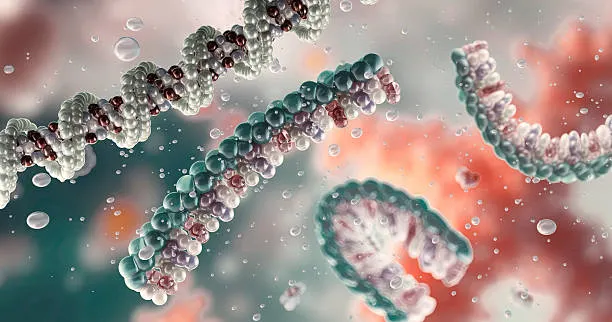

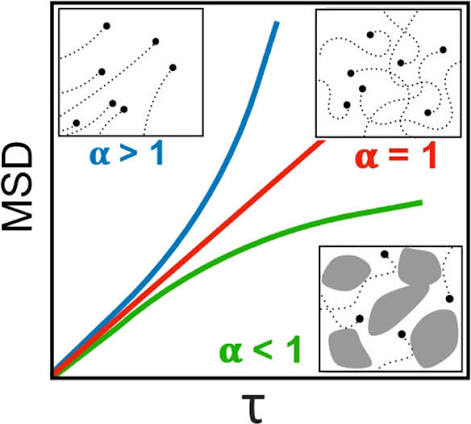


Example of Superdiffusion, Normal diffusion and Subdiffusion.

# **The Paper:**

Physical Nature of Bacterial Cytoplasm, Ido Golding and Edward C. Cox, 2006, Department of Molecular Biology, Princeton University, Princeton, New Jersey 08544, USA
DOI: https://doi.org/10.1103/PhysRevLett.96.098102

# **What The Paper Does**

The paper investigates molecular motion inside bacterial cytoplasm by tracking fluorescently labelled mRNA molecules in *E. coli*. The paper discovered the mRNA shows subdiffusive motion rather than normal diffusion. A subdiffusion expontent is presented that is robust across different conditions. The molecules motion are characterized by localized trapping followed by fast jumps. The paper conclude that the subdiffusion is not explained by cytoskeletal elements.

# **Data Object:**

The trajectory of a single RNA molecule stored as x and y coordinates.

# **Random Variable Chosen:**

The squared distance a molecule moves in a time gap τ (tau).

# **The Generative Model Proposed:**

The paper does not publish the raw particle trajectories, only figures and summary values (α and Γ(gamma)). We therefore used a Monte Carlo simulation to generate our own particle trajectories. The model parameters are θ = (ν, σ).

# **Parameters and Assumptions:**

*   v = 1.7 as exponent, taken from paper's Power law finding.
*   Movement distance sigma, σ. Not real biological behaviour but used for ease of modelling.
*   Tau intervals selected to get range of jump detection for MSD calculation.
*   "Molecule" starting position assumes to be 0 for computational convenvence. In paper it is defined by observation of molecule via microscopy.
*   Shortest possible traptime being 0.1 assumed for computational convenience.
*   Sub diffusive coefficient (α): We used the sub-diffusive coefficient reported in the research paper as a reference in our coding and thought process.
*  "Cage time" (tc): This time interval defines how much time a particle becomes "trapped" within the cytoplasm before a distance displacement is observed.
*   We also assumed that the "trapped" particles where completly frozen and unable to move throughout the trapped time.



# **The Forward Simulation:**

We ran a Monte Carlo simulation to generate a dataset taking into account the molecules behaviour as proposed by the paper's Power law. We used an inverse transform sampling method on the power law to calculate the trapping time, and random jumps between traps to move the molecule, recording its position once per second like the paper's camera.

# **The Parameterization/Fitting:**

Changing the parameters ν and σ showed that ν controls the slope α while σ only changes the height Γ, so we fitted ν to the paper's α = 0.70 (giving ν ≈ 1.7, range 1.6 to 1.8) and σ to the paper's Γ range (giving σ ≈ 0.02 to 0.03 µm).

**What/if the model adds to the paper?**
*   It estimates what the traps would need to look like - v between 1.6 - 1.8.
*   It estimates the jump size. Matching the paper's Γ range requires jumps of about 0.02 to 0.03 µm


# **Model Limitations/How It Breaks:**

*   The Monte Carlo simulation is limited by its high computational cost, additionally the modeling is also highly dependent on the quality of the input data.
*  MSD is not tracked along the 30 min video, just the start. Does not fully replicate the papers measurements.
*  Simplfied version of cytoplasm. 2D model with no cell walls or organelles. No crowding modelled.  
*   The Powerlaw and its exponent is assumed and not demonstrated in lieu of raw data.
*   Model-wise the variable v must be between 1 and 2 or else a division by zero happens(if v=1) or it is no longer subdiffusive (if v=2).









## 1. Setup: particle_tracer and run_ensemble

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Cage time equation. P(t_c) ~ t_c^(−ν), and then α = ν − 1
rng = np.random.default_rng()

taus = [1, 2, 5, 10, 20, 50, 100]   # Chosen tau intervals
taus_arr = np.array(taus)
video_length = 101                  # Only frames 0 to 100 are read, so 101 s is enough
N = 300                             # Number of molecules per run. Tried higher -> same around 0.7. Tried lower(30)



# One molecule: x and y for every second of the video
def particle_tracer(v, video_length, sigma):
    coordinates_x = [0.0] * video_length
    coordinates_y = [0.0] * video_length
    x = 0
    y = 0
    next_jump = 0.1 * (1 - rng.random()) ** (-1/(v-1))   # 0.1 s is the shortest possible trap
    for i in range(video_length):                         # the camera clock. Starts at with a trap - an assuption/limitation.
        while next_jump <= i:                             # has the trap ended yet?
            x = x + rng.normal(0, sigma)                  # jump, typical size sigma
            y = y + rng.normal(0, sigma)
            next_jump = next_jump + 0.1 * (1 - rng.random()) ** (-1/(v-1))   # schedule the next jump
        coordinates_x[i] = x
        coordinates_y[i] = y
    #print(next_jump)
    return coordinates_x, coordinates_y

# N molecules run. MSD measured from the start, returns alpha (slope), Gamma (height) and the MSD values
def run_ensemble(v, sigma):
    all_x = []
    all_y = []
    for p in range(N):
        xs, ys = particle_tracer(v, video_length, sigma)                  #Saves the coordinates for each particle.
        all_x.append(xs)                                                  #One molecules coordinates in one list.
        all_y.append(ys)
    all_x = np.array(all_x)           # shape: (N molecules, video_length frames)
    all_y = np.array(all_y)
    msd = []
    for tau in taus:
        msd.append(np.mean(all_x[:, tau]**2 + all_y[:, tau]**2))   # squared distance from the start, averaged over N
    slope, intercept = np.polyfit(np.log10(taus), np.log10(msd), 1)   # Get the slope and y-axis intercept
    return slope, 10**intercept, msd

Our Monte Carlo is based on the Power law equation - P(t_c) ~ t_c^(−ν).

## 2. Forward run
One molecule's path over 1800 seconds and the MSD of 300 molecules with ν = 1.7, σ = 0.05 µm.

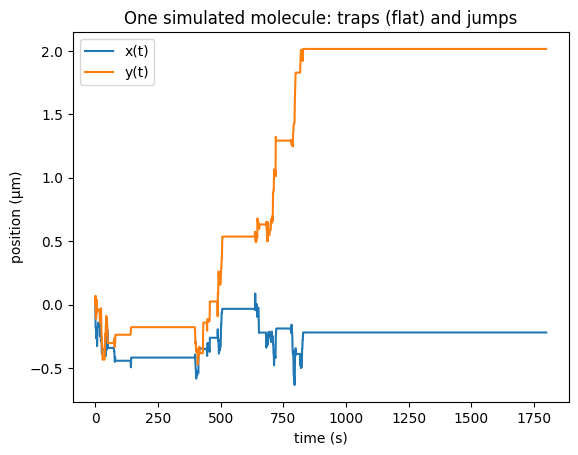

alpha = 0.72   (paper: 0.70 ± 0.07)
Gamma = 0.0092   (paper: about 0.001 to 0.01)


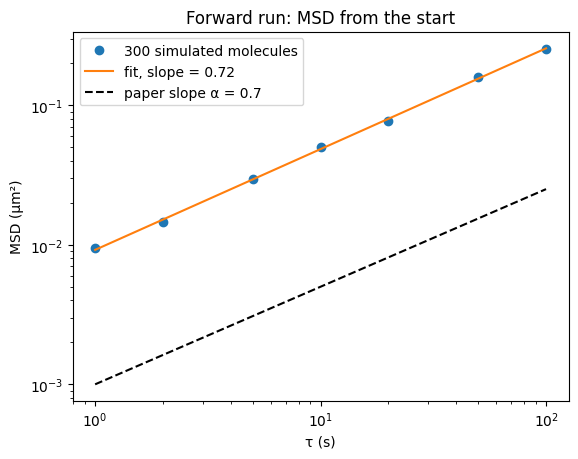

In [ ]:
# One forward run with the starting values
v = 1.7          # nu, parameter controlling how often very long traps happen
sigma = 0.05     # typical jump size in µm.

# A single molecule over 30 minutes, like the paper's Fig 1b
xs, ys = particle_tracer(v, 1800, sigma)

plt.figure()
plt.plot(xs, label="x(t)")
plt.plot(ys, label="y(t)")
plt.xlabel("time (s)")
plt.ylabel("position (µm)")
plt.title("One simulated molecule: traps (flat) and jumps")
plt.legend()
plt.show()

# MSD of N molecules
alpha, Gamma, msd = run_ensemble(v, sigma)
print("alpha =", round(alpha, 2), "  (paper: 0.70 ± 0.07)")
print("Gamma =", round(Gamma, 4), "  (paper: about 0.001 to 0.01)")

plt.figure()
plt.loglog(taus, msd, "o", label= "300 simulated molecules")
plt.loglog(taus, Gamma * taus_arr**alpha, "-", label=f"fit, slope = {alpha:.2f}")
plt.loglog(taus, 0.001 * taus_arr**0.7, "k--", label="paper slope α = 0.7")
plt.xlabel("τ (s)")
plt.ylabel("MSD (µm²)")
plt.title("Forward run: MSD from the start")
plt.legend()
plt.show()

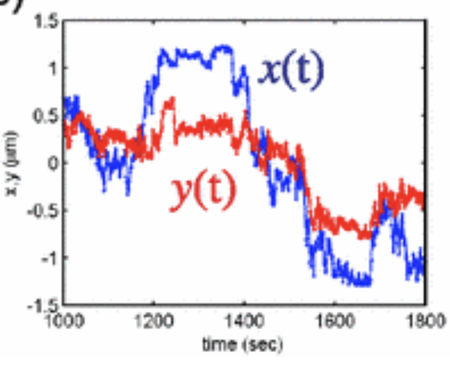

*Figure 1b from Golding & Cox (2006): x and y position of one tagged RNA molecule over time.*

## 3. Sweep 1: ν (backward fit for α, with uncertainty)
Each ν is run R times. The best ν is the one closest to α = 0.70. Every ν inside 0.63 to 0.77 fits the paper.

nu = 1.30   alpha = 0.42 ± 0.03
nu = 1.40   alpha = 0.50 ± 0.02
nu = 1.50   alpha = 0.57 ± 0.02
nu = 1.55   alpha = 0.61 ± 0.03
nu = 1.60   alpha = 0.65 ± 0.03
nu = 1.65   alpha = 0.68 ± 0.03
nu = 1.70   alpha = 0.70 ± 0.03
nu = 1.75   alpha = 0.75 ± 0.02
nu = 1.80   alpha = 0.76 ± 0.02
nu = 1.85   alpha = 0.79 ± 0.02
nu = 1.90   alpha = 0.80 ± 0.02
Best nu: 1.7
nu values that fit the paper: [1.6, 1.65, 1.7, 1.75, 1.8]


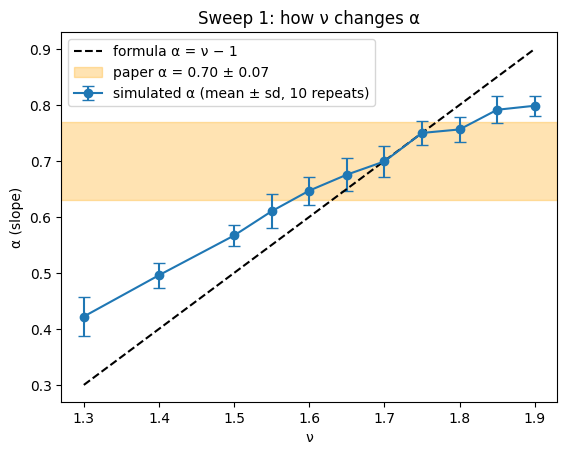

In [ ]:
# Sweep 1: change nu, keep sigma fixed, repeat each R times
v_values = [1.3, 1.4, 1.5, 1.55, 1.6, 1.65, 1.7, 1.75, 1.8, 1.85, 1.9]
sigma_fixed = 0.05
R = 10                              # Repeats per setting, to measure uncertainty

alpha_mean = []
alpha_sd = []
for v_try in v_values:
    alphas = []
    for r in range(R):
        a, G, m = run_ensemble(v_try, sigma_fixed)
        alphas.append(a)
    alpha_mean.append(np.mean(alphas))
    alpha_sd.append(np.std(alphas))
    print(f"nu = {v_try:.2f}   alpha = {np.mean(alphas):.2f} ± {np.std(alphas):.2f}")

# Backward simulation setecting best nu. Also showing every nu that lands inside the paper's range of 0.63 and 0.77
best_v = v_values[np.argmin(np.abs(np.array(alpha_mean) - 0.70))] # alpha mean - 0.7, remove +-, and get minimum.
fits_v = []
for k in range(len(v_values)):                                    # Goes through and see if fit papers range, store in fits_v
    if alpha_mean[k] >= 0.63:
        if alpha_mean[k] <= 0.77:
            fits_v.append(v_values[k])
print("Best nu:", best_v)
print("nu values that fit the paper:", fits_v)
# Plot the figure with the papers range and the formula for exponent alpha.
plt.figure()
plt.errorbar(v_values, alpha_mean, yerr=alpha_sd, fmt="o-", capsize=4,
             label=f"simulated α (mean ± sd, {R} repeats)")
plt.plot(v_values, np.array(v_values) - 1, "k--", label="formula α = ν − 1")
plt.axhspan(0.63, 0.77, color="orange", alpha=0.3, label="paper α = 0.70 ± 0.07")
plt.xlabel("ν")
plt.ylabel("α (slope)")
plt.title("Sweep 1: how ν changes α")
plt.legend()
plt.show()

Shows which of the different candidate v:s fits in the paper's range for alpha using our simulation. A best v is fitted.

## 4. Sweep 2: σ (backward fit for Γ, with uncertainty)
Uses the best ν from Sweep 1. Every σ whose Γ lands in 0.001 to 0.01 fits the paper.

sigma = 0.010   Gamma = 0.0004 ± 0.0000   alpha = 0.70
sigma = 0.015   Gamma = 0.0010 ± 0.0001   alpha = 0.68
sigma = 0.020   Gamma = 0.0016 ± 0.0001   alpha = 0.71
sigma = 0.030   Gamma = 0.0036 ± 0.0002   alpha = 0.71
sigma = 0.040   Gamma = 0.0066 ± 0.0006   alpha = 0.71
sigma = 0.050   Gamma = 0.0102 ± 0.0007   alpha = 0.70
sigma = 0.070   Gamma = 0.0197 ± 0.0011   alpha = 0.71
sigma = 0.100   Gamma = 0.0404 ± 0.0031   alpha = 0.71
sigma values that fit the paper: [0.02, 0.03, 0.04]


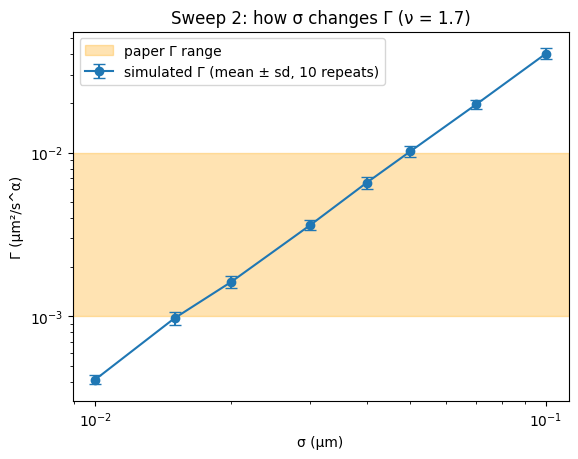

In [ ]:
# Sweep 2: change sigma, keep nu at the best value, repeat each R times
sigma_values = [0.01,0.015, 0.02, 0.03, 0.04, 0.05, 0.07, 0.1]

Gamma_mean = []
Gamma_sd = []
alpha_s = []
for s in sigma_values:
    Gammas = []
    alphas = []
    for r in range(R):
        a, G, m = run_ensemble(best_v, s)
        Gammas.append(G)
        alphas.append(a)
    Gamma_mean.append(np.mean(Gammas))
    Gamma_sd.append(np.std(Gammas))
    alpha_s.append(np.mean(alphas))
    print(f"sigma = {s:.3f}   Gamma = {np.mean(Gammas):.4f} ± {np.std(Gammas):.4f}   alpha = {np.mean(alphas):.2f}")

# Backward: every sigma that lands inside the paper's Gamma range
fits_s = []
for k in range(len(sigma_values)):
  if Gamma_mean[k] >= 0.001:
    if Gamma_mean[k] <= 0.01:
      fits_s.append(sigma_values[k])

print("sigma values that fit the paper:", fits_s)

plt.figure()
plt.errorbar(sigma_values, Gamma_mean, yerr=Gamma_sd, fmt="o-", capsize=4,
             label=f"simulated Γ (mean ± sd, {R} repeats)")
plt.axhspan(0.001, 0.01, color="orange", alpha=0.3, label="paper Γ range")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("σ (µm)")
plt.ylabel("Γ (µm²/s^α)")
plt.title(f"Sweep 2: how σ changes Γ (ν = {best_v})")
plt.legend()
plt.show()

It estimates the jump size of the particle - the distance a molecule typically spreads in one second. Matching the paper's Γ(gamma) range requires jumps of about 0.02 to 0.03 µm. Gamma the generalize diffusion coefficient, a cell-specific parameter dependent on cell-size, RNA-level etc.